In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from lightgbm import LGBMClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

##defining the features and target variables here

In [2]:
df = pd.read_csv('../bank-additional-full.csv', sep=';')

df = df.drop('duration', axis=1)

X = df.drop('y', axis=1)
y = df['y'].map({'yes': 1, 'no': 0})

#finding categorical and numerical columns
categorical_cols = X.select_dtypes(include='object').columns.tolist()
numeric_cols = X.select_dtypes(exclude='object').columns.tolist()

#covert categories
for col in categorical_cols:
    X[col] = X[col].astype('category')

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)

Categorical columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']
Numeric columns: ['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']


In [3]:
lgbm = LGBMClassifier(
    class_weight='balanced', 
    random_state=1, 
    verbose=-1
)


In [4]:
param_grid = { #hyper parameter grid for random search
    'n_estimators': [100, 200],
    'max_depth': [-1, 10, 20],
    'learning_rate': [0.05, 0.1],
    'num_leaves': [31, 50],
    'min_child_samples': [20, 50]
}

In [5]:
#splitting data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1, stratify=y
)

In [6]:
grid_search = GridSearchCV(
    estimator=lgbm,  # No pipeline!
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    verbose=1,
    scoring='f1'
)

grid_search.fit(X_train, y_train)

#print("\nBest parameters found:", grid_search.best_params_)

#best_model = grid_search.best_estimator_

Fitting 5 folds for each of 48 candidates, totalling 240 fits


GridSearchCV(cv=5,
             estimator=LGBMClassifier(class_weight='balanced', random_state=1,
                                      verbose=-1),
             n_jobs=-1,
             param_grid={'learning_rate': [0.05, 0.1],
                         'max_depth': [-1, 10, 20],
                         'min_child_samples': [20, 50],
                         'n_estimators': [100, 200], 'num_leaves': [31, 50]},
             scoring='f1', verbose=1)

In [7]:
print("Best parameters found:", grid_search.best_params_)

best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Best parameters found: {'learning_rate': 0.05, 'max_depth': 10, 'min_child_samples': 20, 'n_estimators': 100, 'num_leaves': 50}

Accuracy: 0.8481427530954115

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.88      0.91      7310
           1       0.39      0.63      0.48       928

    accuracy                           0.85      8238
   macro avg       0.67      0.75      0.70      8238
weighted avg       0.89      0.85      0.86      8238


Confusion Matrix:
 [[6405  905]
 [ 346  582]]



AUC: 0.8017475028303223


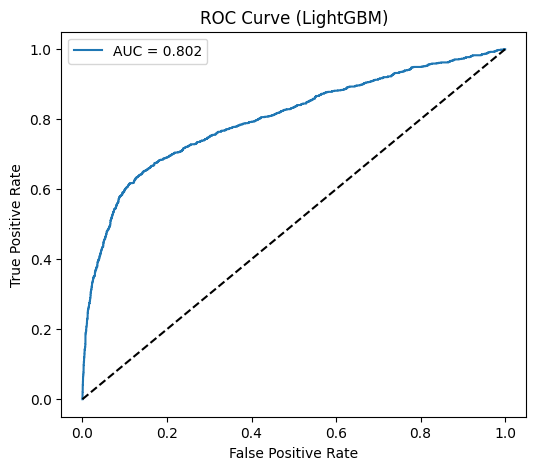

In [8]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

y_proba = best_model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_proba)
print("\nAUC:", auc)

fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (LightGBM)')
plt.legend()
plt.show()

##Using Shap to find and plot the feature importance

In [9]:
import shap
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Take sample
sample_size = 2000  
X_sample = X_test.iloc[:sample_size]
y_sample = y_test.iloc[:sample_size]



# Get feature names directly from X
feature_names = X.columns.tolist()

# Computing SHAP values for LightGBM
print("Calculating SHAP values with LightGBM...")

lgb_model = best_model  # Direct access, no pipeline

#use TreeExplainer
explainer = shap.TreeExplainer(lgb_model)
shap_values = explainer.shap_values(X_sample)

#ff shap_values is a list (binary classification), use the 2nd element
if isinstance(shap_values, list):
    shap_values_class1 = shap_values[1]
else:
    shap_values_class1 = shap_values

print(f" SHAP values calculated. Shape: {shap_values_class1.shape}")

#computing mean SHAP values
mean_abs_shap = np.abs(shap_values_class1).mean(axis=0)

feature_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': mean_abs_shap
}).sort_values('importance', ascending=False)

#displaying top features
top_n = 20
top_features = feature_importance.head(top_n)

print(f"\nTop {top_n} most important features (LightGBM):")
print("="*70)
for i, row in enumerate(top_features.itertuples(), 1):
    print(f"{i:>2}. {row.feature:<45} {row.importance:.6f}")

/Users/iankwak/Documents/Bank_Marketing_ML/src/venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Calculating SHAP values with LightGBM...
 SHAP values calculated. Shape: (2000, 19)

Top 20 most important features (LightGBM):
 1. nr.employed                                   0.432406
 2. contact                                       0.269655
 3. month                                         0.166614
 4. euribor3m                                     0.133874
 5. campaign                                      0.088885
 6. emp.var.rate                                  0.081144
 7. day_of_week                                   0.079107
 8. age                                           0.064274
 9. pdays                                         0.058854
10. job                                           0.056343
11. poutcome                                      0.055937
12. cons.conf.idx                                 0.046668
13. education                                     0.043139
14. default                                       0.033213
15. cons.price.idx                            

/Users/iankwak/Documents/Bank_Marketing_ML/src/venv/lib/python3.9/site-packages/shap/explainers/_tree.py:586: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


##plotting the feature importance


 Saved: LGBM_feature_importance_top20.png


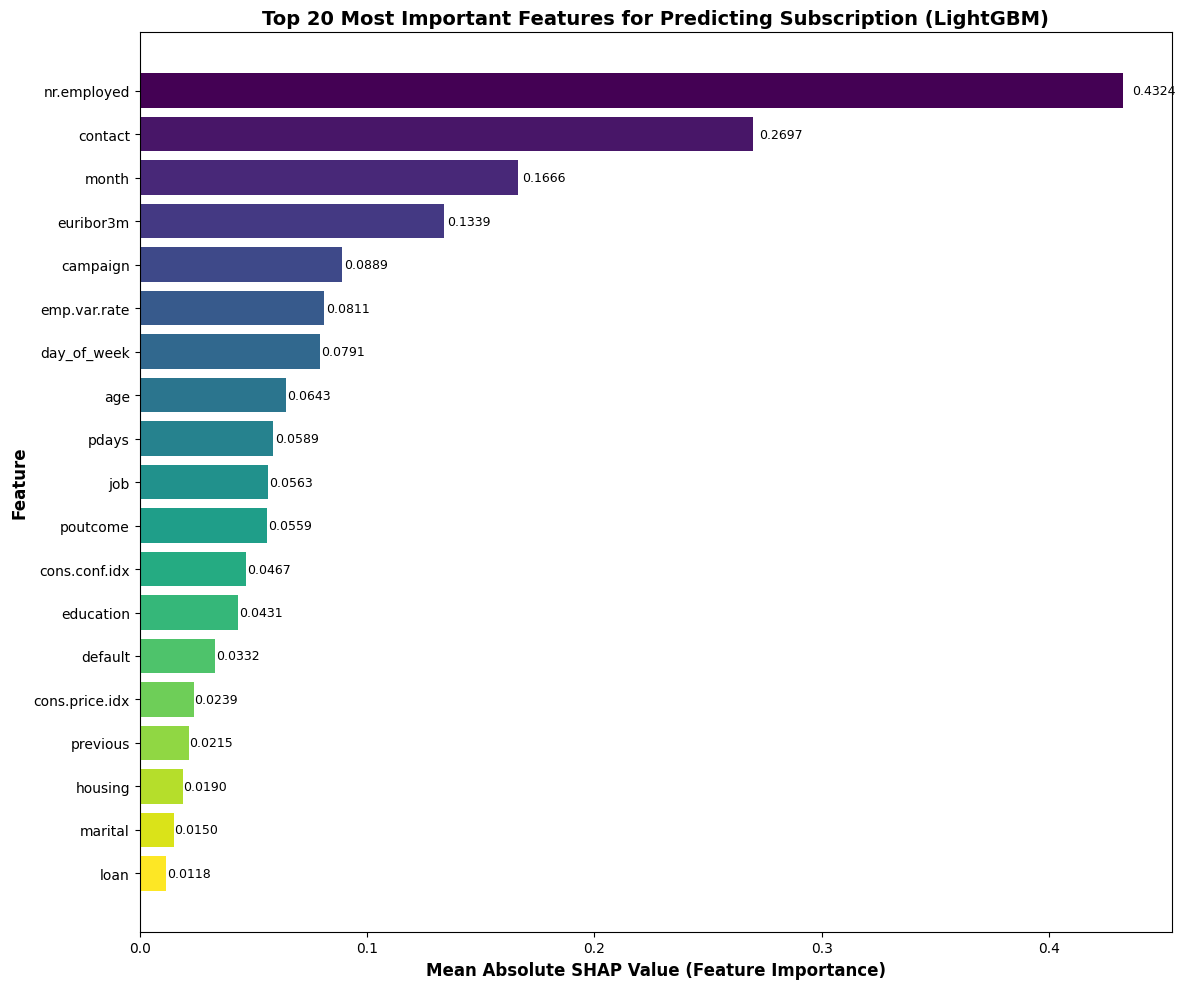

 Saved: LGBM_all_feature_importance.csv (all 19 features)

SUMMARY
Total features analyzed: 19
Most important feature: nr.employed
Importance range: 0.011769 to 0.432406


In [10]:
# Plot
plt.figure(figsize=(12, 10))
colors = plt.cm.viridis(np.linspace(0, 1, len(top_features)))
bars = plt.barh(range(len(top_features)), top_features['importance'], color=colors)
plt.yticks(range(len(top_features)), top_features['feature'], fontsize=10)
plt.xlabel('Mean Absolute SHAP Value (Feature Importance)', fontsize=12, fontweight='bold')
plt.ylabel('Feature', fontsize=12, fontweight='bold')
plt.title(f'Top {top_n} Most Important Features for Predicting Subscription (LightGBM)', 
          fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()

for i, (bar, val) in enumerate(zip(bars, top_features['importance'])):
    plt.text(val + val*0.01, i, f'{val:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(f'output/LGBM_feature_importance_top{top_n}.png', dpi=300, bbox_inches='tight')
print(f"\n Saved: LGBM_feature_importance_top{top_n}.png")
plt.show()

#save results and summary
feature_importance.to_csv('output/LGBM_all_feature_importance.csv', index=False)
print(f" Saved: LGBM_all_feature_importance.csv (all {len(feature_importance)} features)")

print("\n" + "="*70)
print("SUMMARY")
print("="*70)
print(f"Total features analyzed: {len(feature_names)}")
print(f"Most important feature: {top_features.iloc[0]['feature']}")
print(f"Importance range: {feature_importance['importance'].min():.6f} to {feature_importance['importance'].max():.6f}")

categorical_count = sum(1 for f in top_features['feature'] if 'cat__' in f)
numerical_count = sum(1 for f in top_features['feature'] if 'num__' in f)

